In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
sns.set_style("darkgrid")

### Loading the data

In [6]:
df= pd.read_csv(r"customer_segmentation.csv")

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [9]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [10]:
df.shape

(2240, 29)

In [11]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [12]:
df.isna().sum().sum()

24

In [13]:
df.duplicated().sum()

0

In [14]:
df.dropna(subset = ["Income"], inplace = True)

In [15]:
df.isna().sum().sum()

0

### Converting Date col to datetime

In [16]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [18]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [19]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

### Feature Engineering

In [20]:
df["Age"] = 2026 - df["Year_Birth"]

In [21]:
df[["Age"]]

,Age
0,69
1,72
2,61
3,42
4,45
...,...
2235,59
2236,80
2237,45
2238,70


In [22]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [23]:
df[["Total_Children"]]

,Total_Children
0,0
1,2
2,0
3,1
4,1
...,...
2235,1
2236,3
2237,0
2238,1


In [24]:
df[["Total_Children"]].value_counts()

Total_Children
1                 1117
0                  633
2                  416
3                   50
Name: count, dtype: int64

In [25]:
spend_cols = ["MntWines", "MntFruits",
       "MntMeatProducts", "MntFishProducts", "MntSweetProducts",
       "MntGoldProds"]

In [28]:
df["Total_Spending"] = df[spend_cols].sum(axis =1)

In [29]:
df[["Total_Spending"]]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [30]:
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

In [32]:
df[["Customer_Since"]]

,Customer_Since
0,4951
1,4401
2,4600
3,4427
4,4449
...,...
2235,4669
2236,4307
2237,4443
2238,4444


### Age Distribution

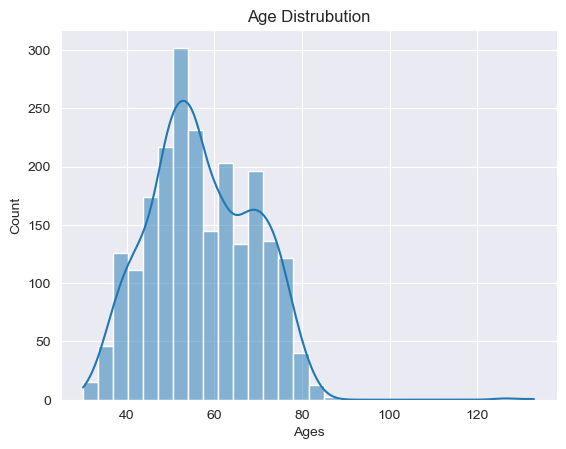

In [33]:
sns.histplot(df["Age"], bins = 30, kde = True)
plt.title("Age Distrubution")
plt.xlabel("Ages")
plt.ylabel("Count")
plt.show()

### Income Distribution

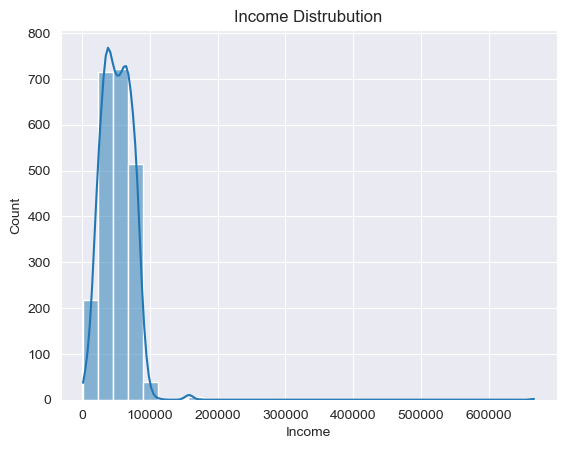

In [34]:
sns.histplot(data = df["Income"], bins = 30, kde = True)
plt.title("Income Distrubution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

### Spending Distribution

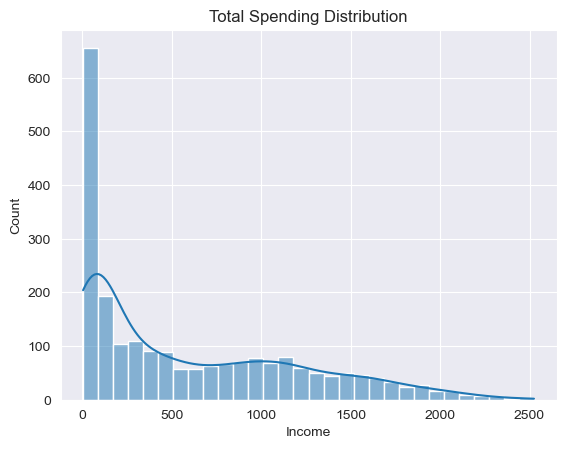

In [35]:
sns.histplot(data = df["Total_Spending"], bins = 30, kde = True)
plt.title("Total Spending Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

## Categorical Analysis

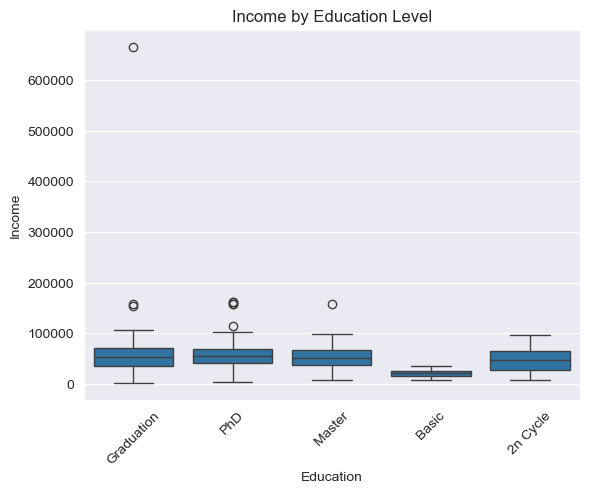

In [36]:
sns.boxplot(data = df, x = "Education", y = "Income")
plt.xticks(rotation = 45)
plt.title("Income by Education Level")
plt.show()

### Spending by Marital Status

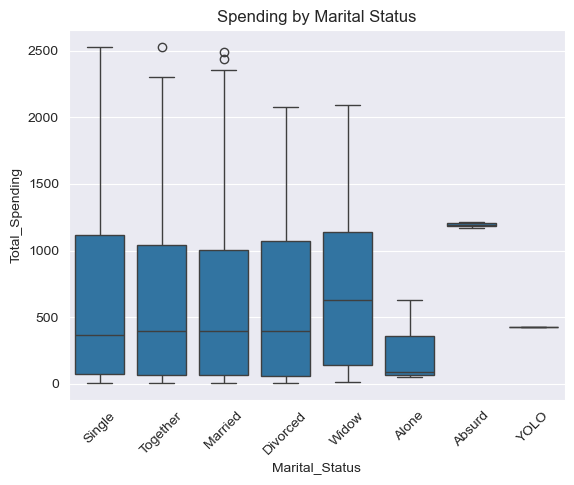

In [37]:
sns.boxplot(data = df, x = df["Marital_Status"], y = df["Total_Spending"])
plt.xticks(rotation = 45)
plt.title("Spending by Marital Status")
plt.show()

## Correlation Analysis

In [38]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='object')

In [39]:
corr = df[["Income", "Age","Recency", "Total_Spending", "NumWebPurchases","NumStorePurchases" ]].corr()

In [40]:
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_Spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


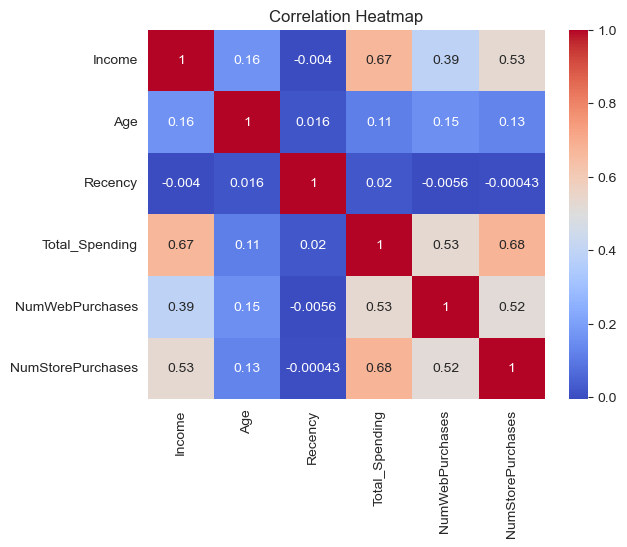

In [42]:
sns.heatmap(corr, annot = True, cmap = "coolwarm")
#plt.figure(figsize = (8,9))
plt.title("Correlation Heatmap")
plt.show()

## Pivot

In [43]:
 pivot_income = df.pivot_table(values = "Income", index = "Education", columns = "Marital_Status", aggfunc = "mean")

In [44]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


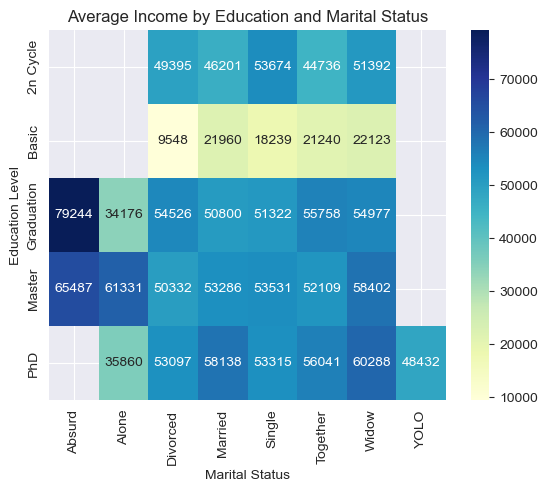

In [45]:
sns.heatmap(pivot_income, annot = True, fmt = ".0f", cmap = "YlGnBu")
plt.title("Average Income by Education and Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Education Level")
plt.show()

In [47]:
df["Kidhome"].value_counts()

Kidhome
0    1283
1     887
2      46
Name: count, dtype: int64

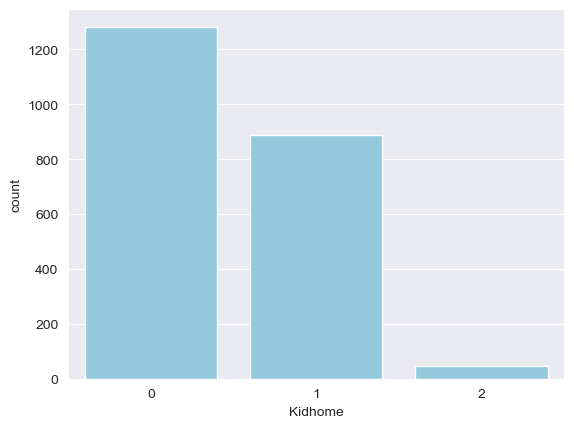

In [48]:
sns.barplot(data = df["Kidhome"].value_counts(), color = "skyblue")
plt.show()

In [49]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending = False) 

In [52]:
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

### Average Spending by Education

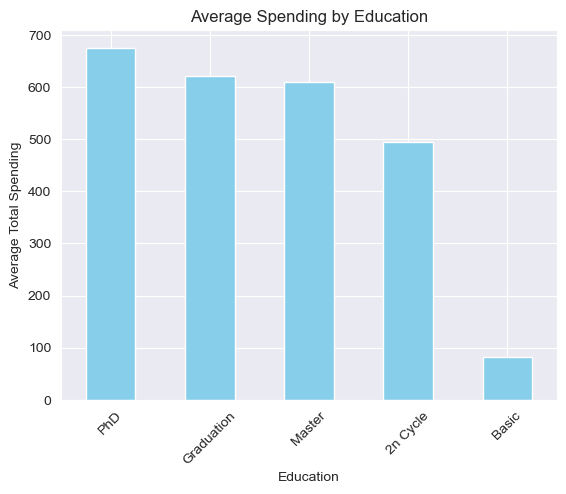

In [53]:
group1.plot(kind = "bar", color = "skyblue")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation = 45)
plt.show()

In [55]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='object')

In [56]:
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4","AcceptedCmp5", "Response"]].sum(axis =1 )

In [57]:
df[["AcceptedAny"]]

,AcceptedAny
0,1
1,0
2,0
3,0
4,0
...,...
2235,0
2236,1
2237,1
2238,0


In [58]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5], dtype=int64)

In [59]:
df["AcceptedAny"] = df["AcceptedAny"].apply(lambda x: 1 if x > 0 else 0)

In [60]:
df["AcceptedAny"].unique()

array([1, 0], dtype=int64)

In [61]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending = False)

In [62]:
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

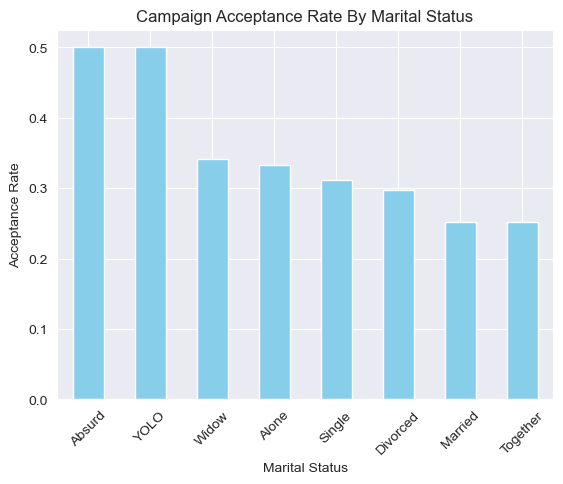

In [63]:
group2.plot(kind = "bar", color = "Skyblue")
plt.title("Campaign Acceptance Rate By Marital Status")
plt.ylabel("Acceptance Rate")
plt.xlabel("Marital Status")
plt.xticks(rotation = 45)
plt.show()

### Average Income by Age Group

In [64]:
bin = [18, 30, 40, 50, 60, 70, 90]

In [65]:
label = ["18-29","30-39", "40-49", "50-59", "60-69", "70+"]

In [66]:
df["AgeGroup"] = pd.cut(df["Age"], bins = bin, labels = label)

In [67]:
df[["AgeGroup"]]

,AgeGroup
0,60-69
1,70+
2,60-69
3,40-49
4,40-49
...,...
2235,50-59
2236,70+
2237,40-49
2238,60-69


In [68]:
group3 = df.groupby("AgeGroup")["Income"].mean()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12608\1140876350.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby("AgeGroup")["Income"].mean()


In [69]:
group3

AgeGroup
18-29    10960.500000
30-39    47905.475676
40-49    48057.587649
50-59    50479.321534
60-69    55980.030928
70+      58767.083102
Name: Income, dtype: float64

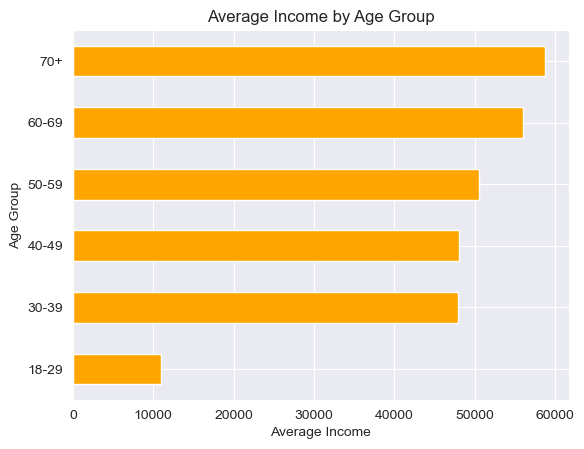

In [70]:
group3.plot(kind = "barh", color = "orange")
plt.title("Average Income by Age Group")
plt.ylabel("Age Group")
#plt.xticks(rotation = 90)
plt.xlabel("Average Income")
plt.show()

In [71]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,69,0,1617,4951,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,72,2,27,4401,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,61,0,776,4600,0,60-69
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,42,1,53,4427,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,45,1,422,4449,0,40-49


In [72]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

### Selecting Columns that rep Customer Demographic

 Age - Income - TotalSpending - NumWebPurchases - NumStorePurchases - NumWebVisitsMonth - Recency 

In [73]:
features = ["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]

In [74]:
X = df[features].copy()

In [75]:
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,69,58138.0,1617,8,4,7,58
1,72,46344.0,27,1,2,5,38
2,61,71613.0,776,8,10,4,26
3,42,26646.0,53,2,4,6,26
4,45,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,59,61223.0,1341,9,4,5,46
2236,80,64014.0,444,8,5,7,56
2237,45,56981.0,1241,2,13,6,91
2238,70,69245.0,843,6,10,3,8


### Scaling

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [77]:
X_scaled = scaler.fit_transform(X)

In [78]:
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]])

### Using Kmeans for the Clustering

In [79]:
from sklearn.cluster import KMeans

In [80]:
wcss = []

In [81]:
for i in range (2, 10):
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [82]:
wcss

[10218.648106906192,
 9007.786818672812,
 8239.311792375798,
 7568.495503526837,
 7162.990769916766,
 6604.6009395041965,
 6475.416492548258,
 5907.2726224929165]

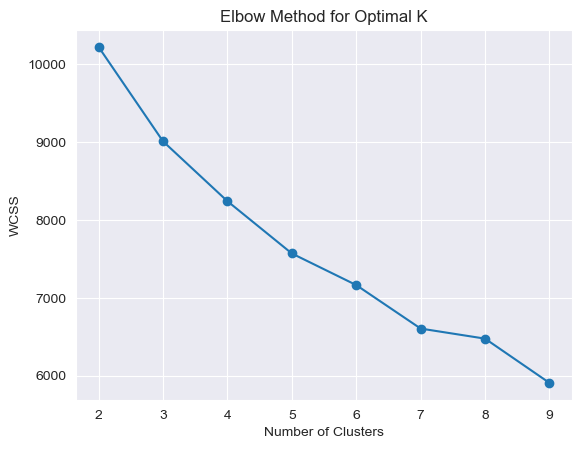

In [83]:
plt.plot(range(2, 10), wcss, marker = "o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [84]:
kmeans = KMeans(n_clusters = 6)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [85]:
df["Cluster"]

0       0
1       2
2       0
3       2
4       1
       ..
2235    0
2236    0
2237    4
2238    3
2239    2
Name: Cluster, Length: 2216, dtype: int32

### Lets Analyse the Clusters

In [86]:
cluster_summary = df.groupby("Cluster")[features].mean()

In [87]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,60.645238,59409.361905,875.426190,7.947619,7.754762,6.445238,46.161905
1,56.111732,36419.184358,135.547486,2.415270,3.478585,6.420857,75.372439
2,53.287456,34430.761324,118.364111,2.207317,3.336237,6.545296,24.655052
3,71.136905,72344.767857,1139.663690,4.517857,8.270833,2.750000,51.967262
4,47.612069,76244.568966,1304.255747,4.683908,8.715517,2.715517,49.175287
5,49.000000,666666.000000,62.000000,3.000000,3.000000,6.000000,23.000000


In [88]:
df["Cluster"].value_counts()

Cluster
2    574
1    537
0    420
4    348
3    336
5      1
Name: count, dtype: int64

### Visualize the Clusters

In [89]:
from sklearn.decomposition import PCA

In [90]:
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:,0], pca_data[:,1]

In [91]:
pca_data

array([[ 1.1075188 ,  0.21175951],
       [-1.33673385, -0.269839  ],
       [ 1.88227676,  1.01416098],
       ...,
       [ 1.1535966 , -1.15056999],
       [ 1.88768024,  1.16073698],
       [-0.84182091,  0.15963623]])

In [92]:
df["PCA1"]

0       1.107519
1      -1.336734
2       1.882277
3      -1.784359
4       0.020363
          ...   
2235    1.248177
2236    0.508708
2237    1.153597
2238    1.887680
2239   -0.841821
Name: PCA1, Length: 2216, dtype: float64

In [93]:
df["PCA2"]

0       0.211760
1      -0.269839
2       1.014161
3       0.704928
4      -1.235265
          ...   
2235    0.535766
2236    0.141328
2237   -1.150570
2238    1.160737
2239    0.159636
Name: PCA2, Length: 2216, dtype: float64

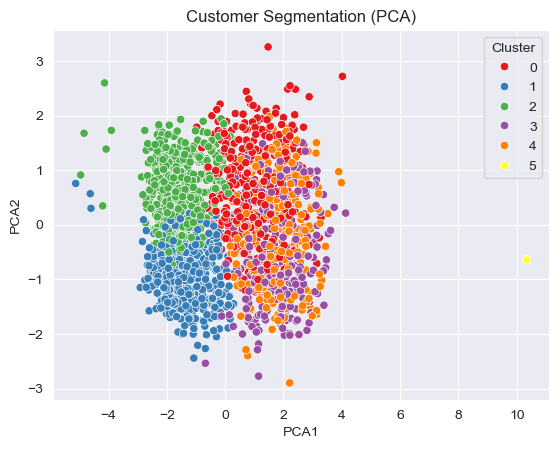

In [94]:
sns.scatterplot(x = "PCA1", y = "PCA2", hue = "Cluster", data = df, palette = "Set1")
plt.title("Customer Segmentation (PCA)")
plt.show()

In [95]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,60.645238,59409.361905,875.426190,7.947619,7.754762,6.445238,46.161905
1,56.111732,36419.184358,135.547486,2.415270,3.478585,6.420857,75.372439
2,53.287456,34430.761324,118.364111,2.207317,3.336237,6.545296,24.655052
3,71.136905,72344.767857,1139.663690,4.517857,8.270833,2.750000,51.967262
4,47.612069,76244.568966,1304.255747,4.683908,8.715517,2.715517,49.175287
5,49.000000,666666.000000,62.000000,3.000000,3.000000,6.000000,23.000000


In [96]:
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)

Cluster
0    420
1    537
2    574
3    336
4    348
5      1
Name: count, dtype: int64


# Customer Segmentation Analysis Report

## Overview
Based on the clustering analysis, we have identified 6 distinct customer segments with unique characteristics, behaviors, and value propositions. Total customers analyzed: **2,216**

## Customer Distribution Summary

| Cluster | Name | Count | Percentage |
|---------|------|-------|------------|
| 0 | 🌟 Engaged Affluents | 420 | 19.0% |
| 1 | 🛒 Budget-Conscious Shoppers | 537 | 24.2% |
| 2 | ⏰ Recent Budget Shoppers | 574 | 25.9% |
| 3 | 👴 Traditional High-Spenders | 336 | 15.2% |
| 4 | 💎 Premium Store Shoppers | 348 | 15.7% |
| 5 | ⚠️ Outlier | 1 | 0.05% |
| **Total** | | **2,216** | **100%** |

# Cluster 0: 🌟 Engaged Affluents
**Size:** 420 customers (19.0% of total)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Age | 60.6 years | Mature, established customers |
| Income | $59,409 | Upper-middle income bracket |
| Total Spending | $875 | High-value purchases |
| Web Purchases | 7.95 | High digital engagement |
| Store Purchases | 7.75 | Balanced omnichannel behavior |
| Web Visits/Month | 6.45 | Frequent online browsing |
| Recency | 46.2 days | Moderate recency |

**Profile Summary:**
These are mature, affluent customers who engage heavily across both online and offline channels. They are consistent purchasers with balanced shopping habits. This segment represents 19% of your customer base.

**Key Characteristics:**
- High income with corresponding high spending
- True omnichannel customers (web + store purchases nearly equal)
- Frequent website visitors
- Established, loyal customer base

**Marketing Strategy:**
- Cross-channel promotions
- Loyalty program enrollment
- Premium product recommendations
- Email newsletters with new arrivals

# Cluster 1: 🛒 Budget-Conscious Shoppers
**Size:** 537 customers (24.2% of total)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Age | 56.1 years | Middle-aged customers |
| Income | $36,419 | Lower-middle income bracket |
| Total Spending | $136 | Low-value purchases |
| Web Purchases | 2.42 | Limited digital purchases |
| Store Purchases | 3.48 | Slightly prefers in-store |
| Web Visits/Month | 6.42 | Active browsers |
| Recency | 75.4 days | Dormant/lapsed customers |

**Profile Summary:**
Price-sensitive customers with limited purchasing power who browse frequently but buy sparingly. Their high recency score indicates they haven't purchased recently. This is your largest segment at 24.2% of customers.

**Key Characteristics:**
- Lower income with conservative spending
- Active browsers but infrequent purchasers
- At risk of churn (high recency)
- May be comparison shopping

**Marketing Strategy:**
- Discount offers and promotions
- Re-engagement campaigns
- Budget-friendly product recommendations
- Clearance and sale alerts

# Cluster 2: ⏰ Recent Budget Shoppers
**Size:** 574 customers (25.9% of total)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Age | 53.3 years | Middle-aged |
| Income | $34,430 | Lower-middle income |
| Total Spending | $118 | Low-value purchases |
| Web Purchases | 2.21 | Minimal digital purchases |
| Store Purchases | 3.34 | Store preference |
| Web Visits/Month | 6.55 | Frequent browsers |
| Recency | 24.7 days | Recently active |

**Profile Summary:**
Similar to Cluster 1 but actively engaged recently. These customers are budget-conscious but currently in the consideration phase. This is your largest segment at 25.9% of customers.

**Key Characteristics:**
- Lower income with conservative spending
- Recently active customers
- High browsing activity
- Potential for conversion with right incentives

**Marketing Strategy:**
- Capitalize on recent engagement
- Limited-time offers
- Cart abandonment reminders
- Small-ticket item recommendations

# Cluster 3: 👴 Traditional High-Spenders
**Size:** 336 customers (15.2% of total)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Age | 71.1 years | Senior segment |
| Income | $72,345 | High income |
| Total Spending | $1,140 | High-value purchases |
| Web Purchases | 4.52 | Moderate digital adoption |
| Store Purchases | 8.27 | Strong store preference |
| Web Visits/Month | 2.75 | Low digital engagement |
| Recency | 51.9 days | Moderate recency |

**Profile Summary:**
Older, affluent customers who strongly prefer in-store shopping. They make high-value purchases but have limited digital engagement. Represents 15.2% of your customer base.

**Key Characteristics:**
- Highest age segment
- Strong in-store purchase behavior
- Low digital comfort/frequency
- High transaction values when they purchase

**Marketing Strategy:**
- Direct mail campaigns
- In-store events and promotions
- Traditional advertising channels
- Senior discounts and loyalty benefits
- Assisted shopping experiences

# Cluster 4: 💎 Premium Store Shoppers
**Size:** 348 customers (15.7% of total)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Age | 47.6 years | Prime earning years |
| Income | $76,245 | High income bracket |
| Total Spending | $1,304 | HIGHEST spending |
| Web Purchases | 4.68 | Moderate digital |
| Store Purchases | 8.72 | STRONG store preference |
| Web Visits/Month | 2.72 | Low browsing |
| Recency | 49.2 days | Moderate recency |

**Profile Summary:**
**HIGHEST VALUE SEGMENT** - Affluent, middle-aged customers who prefer in-store shopping and make the largest purchases. This is your premium customer base, representing 15.7% of customers but likely driving disproportionate revenue.

**Key Characteristics:**
- Highest spending of all clusters
- Highest income bracket
- Strong store preference
- Efficient shoppers (low browsing, high purchase)
- Prime demographic for luxury goods

**Marketing Strategy:**
- VIP treatment and exclusive events
- Premium product launches
- Personal shopping services
- Concierge-level customer service
- Early access to new collections
- High-end loyalty tiers

# Cluster 5: ⚠️ Outlier - Remove from Analysis
**Size:** 1 customer (0.05% of total)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Age | 49.0 years | Middle-aged |
| Income | $666,666 | EXTREME OUTLIER |
| Total Spending | $62 | Minimal spending |
| Web Purchases | 3.00 | Average |
| Store Purchases | 3.00 | Average |
| Web Visits/Month | 6.00 | Average |
| Recency | 23.0 days | Recent |

**Profile Summary:**
**⚠️ SINGLE OUTLIER - EXCLUDE FROM ANALYSIS**

This is a single anomalous data point that doesn't represent a meaningful customer segment. The income value is unrealistic compared to all other metrics.

**Recommended Action:**
- **Remove this customer** from the segmentation analysis
- Investigate source: likely data entry error or test account
- For production model, implement outlier detection to exclude such cases

**If you choose to keep (not recommended):**
- Treat as special case for high-net-worth individuals
- Monitor for similar patterns in new data



### Revenue Impact Analysis

While Clusters 1 & 2 represent **50.1% of our customers** (1,111 customers), they contribute relatively low spending. In contrast:

- **Clusters 3 & 4** represent only **30.9% of customers** (684 customers) but drive the highest spending
- **Focus retention efforts on Clusters 3 & 4** - losing these customers would significantly impact revenue
- **Clusters 1 & 2** represent the biggest growth opportunity - small increases in their spending could yield significant returns

### Immediate Action Items

1. **Remove Cluster 5** from future analysis (single outlier)
2. **VIP Program**: Create exclusive program for Clusters 3 & 4
3. **Digital Education**: Campaigns for Cluster 3 to increase online engagement
4. **Conversion Campaign**: Target Cluster 2 with offers while they're active
5. **Re-engagement**: Win-back campaigns for Cluster 1

### Strategic Initiatives

- **Cross-Sell**: Between Cluster 0 (digital-savvy) and Cluster 4 (high-value)
- **Lookalike Modeling**: Find more customers like Cluster 4
- **Data Validation**: Implement checks for income data to prevent outliers
- **A/B Testing**: Test promotions on Clusters 1 & 2 to identify conversion drivers

In [98]:
df["Recency"]

0       58
1       38
2       26
3       26
4       94
        ..
2235    46
2236    56
2237    91
2238     8
2239    40
Name: Recency, Length: 2216, dtype: int64

In [99]:
import joblib

In [100]:
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [101]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']